In [ ]:
import pandas as pd
from scipy.stats import pearsonr
import math

# === 1. Upload file ===
from google.colab import files
uploaded = files.upload()

# Ganti nama file sesuai yang kamu upload
df = pd.read_excel('data hasil pertanyaan.xlsx')

Saving data hasil pertanyaan.xlsx to data hasil pertanyaan.xlsx


In [ ]:
# === 2. Siapkan r tabel ===
n = df.shape[0]  # jumlah responden
dfree = n - 2
# r tabel untuk alpha 0.05 (dua sisi)
r_tabel = 0.284  # bisa disesuaikan manual jika mau lihat tabel statistik

In [ ]:
# === 3. Hitung korelasi tiap item dengan total skor ===
hasil_validitas = []

total_score = df.sum(axis=1)  # total semua pertanyaan

for col in df.columns:
    r_value, p_value = pearsonr(df[col], total_score)
    status = "Valid" if r_value > r_tabel else "Tidak Valid"
    hasil_validitas.append({
        'Item': col,
        'r_hitung': round(r_value, 3),
        'p_value': round(p_value, 4),
        'r_tabel': r_tabel,
        'Keterangan': status
    })

In [ ]:
# === 4. Simpan ke Excel ===
hasil_df = pd.DataFrame(hasil_validitas)
hasil_df.to_excel('uji_validitas.xlsx', index=False)

# Download file hasil
files.download('uji_validitas.xlsx')

# Tampilkan di output Colab
hasil_df

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

,Item,r_hitung,p_value,r_tabel,Keterangan
0,Q1,0.581,0.0000,0.284,Valid
1,Q2,0.607,0.0000,0.284,Valid
2,Q3,0.738,0.0000,0.284,Valid
3,Q4,0.821,0.0000,0.284,Valid
4,Q5,0.688,0.0000,0.284,Valid
5,Q6,0.756,0.0000,0.284,Valid
6,Q7,0.799,0.0000,0.284,Valid
7,Q8,0.757,0.0000,0.284,Valid
8,Q9,0.656,0.0000,0.284,Valid
9,Q10,0.730,0.0000,0.284,Valid


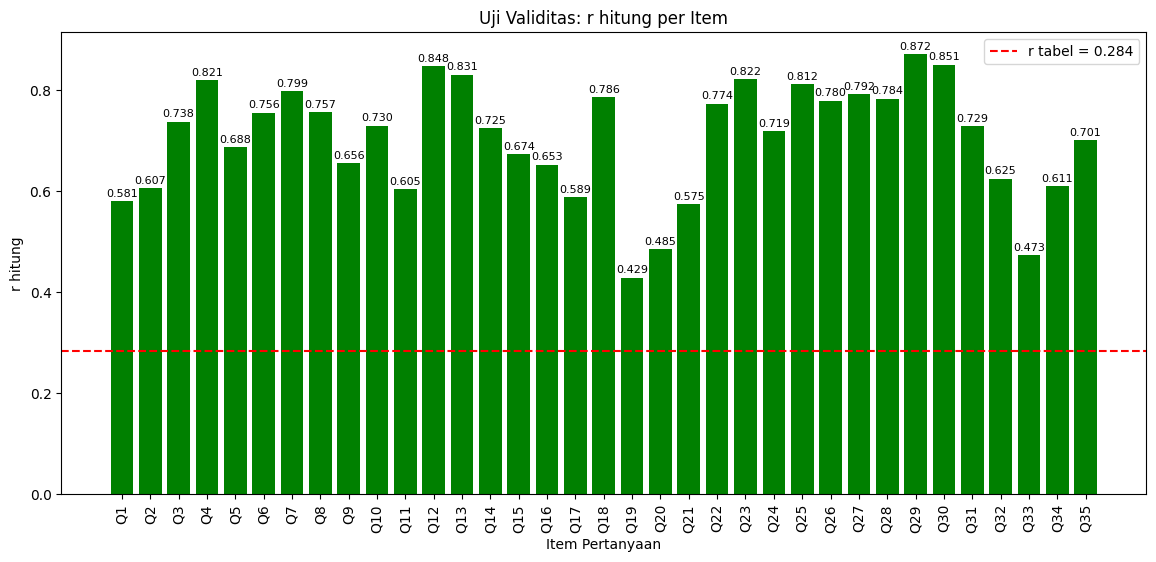

In [ ]:
import matplotlib.pyplot as plt

# Pastikan 'hasil_df' sudah ada dari uji validitas sebelumnya

plt.figure(figsize=(14,6))

# Warna bar: hijau jika valid, merah jika tidak
colors = ['green' if status == 'Valid' else 'red' for status in hasil_df['Keterangan']]

bars = plt.bar(hasil_df['Item'], hasil_df['r_hitung'], color=colors)

# Garis batas r tabel
plt.axhline(y=r_tabel, color='red', linestyle='--', label=f"r tabel = {r_tabel}")

# Label dan judul
plt.xticks(rotation=90)
plt.ylabel("r hitung")
plt.xlabel("Item Pertanyaan")
plt.title("Uji Validitas: r hitung per Item")
plt.legend()

# Tambahkan nilai di atas bar
for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f"{bar.get_height():.3f}",
             ha='center', va='bottom', fontsize=8)

plt.show()


Hasil Uji Validitas Instrumen
Berdasarkan perhitungan korelasi Pearson antara setiap item pertanyaan dengan total skor kuesioner:

Jumlah responden (n): 48 orang

r tabel (α = 0.05, df = 46): 0.284

Kriteria validitas: Item dinyatakan valid apabila r hitung > r tabel

Hasil pengujian menunjukkan bahwa:

Seluruh item pertanyaan memiliki nilai r hitung lebih besar daripada r tabel (r hitung berkisar antara ±0.6 hingga 0.9)

p-value < 0.05 pada semua item, yang berarti hubungan antara item dengan total skor signifikan secara statistik

Dengan demikian, seluruh 35 item kuesioner dinyatakan valid dan layak digunakan dalam penelitian

Insight
Tidak ada item yang perlu dibuang karena semua memenuhi kriteria validitas.

Konsistensi hasil ini sejalan dengan nilai Cronbach’s Alpha yang sangat tinggi (0.969), menunjukkan bahwa instrumen tidak hanya konsisten tetapi juga tepat mengukur konsep yang dimaksud.

Peneliti dapat melanjutkan ke tahap analisis deskriptif dan regresi tanpa perlu revisi instrumen.